### Importing the necessary Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import StandardScaler

In [2]:
# Set the option to display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Loading the dataset

In [3]:
train_dataset = r"./data/train.csv"
test_dataset = r"./data/test.csv"
df_train = pd.read_csv(train_dataset)
df_test = pd.read_csv(test_dataset)

In [4]:
print("The shape of df_train is :",df_train.shape)
print("The shape of df_test is :",df_test.shape)

The shape of df_train is : (1460, 81)
The shape of df_test is : (1459, 80)


In [5]:
df_train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df_test.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


### Data Integration

In [7]:
df = pd.concat([df_train,df_test])
print("The shape of integrated data frame is :",df.shape)

The shape of integrated data frame is : (2919, 81)


In [8]:
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [9]:
df.tail(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,NaN,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,912.0,GasA,TA,Y,SBrkr,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,80,32,0,0,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,2Story,7,5,1993,1994,Gable,CompShg,HdBoard,HdBoard,BrkFace,94.0,TA,TA,PConc,Gd,TA,Av,LwQ,758.0,Unf,0.0,238.0,996.0,GasA,Ex,Y,SBrkr,996,1004,0,2000,0.0,0.0,2,1,3,1,TA,9,Typ,1,TA,Attchd,1993.0,Fin,3.0,650.0,TA,TA,Y,190,48,0,0,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal,NaN


### Getting the info of the dataset

In [10]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1       float64
BsmtFinType2      object
BsmtFinSF2       float64
BsmtUnfSF        float64
TotalBsmtSF      float64
Heating           object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallCond  

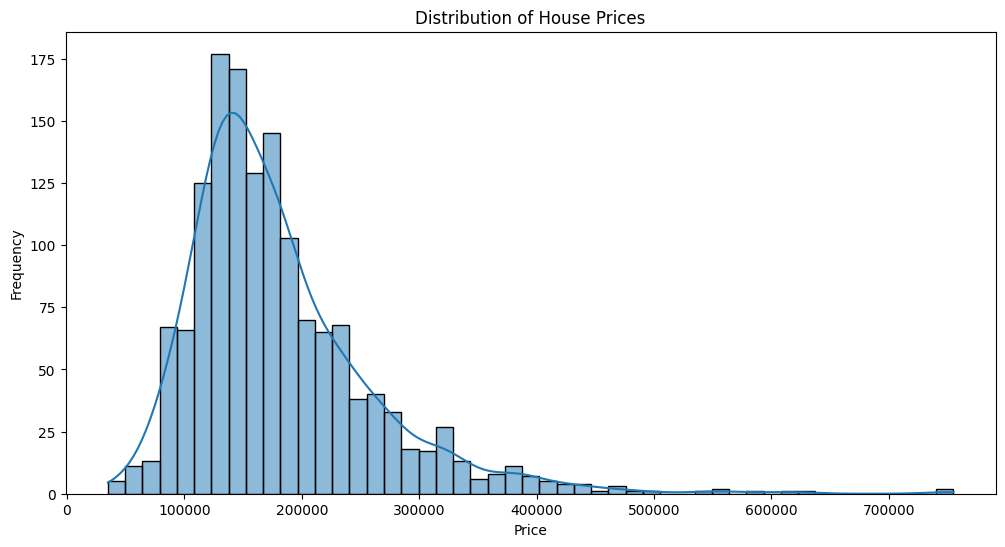

In [12]:
plt.figure(figsize=(12, 6))
sns.histplot(df_train['SalePrice'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [13]:
int_features = df.select_dtypes(include = ["int64"])
print(f"The number of integer features number is : {int_features.shape[1]}")
print(f"The Names of integer features are : {int_features.columns}")

The number of integer features number is : 26
The Names of integer features are : Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')


In [14]:
float_features = df.select_dtypes(include = ["float64"])
print(f"The total number of float features number is : {float_features.shape[1]}")
print(f"The Names of float features are : {float_features.columns}")

The total number of float features number is : 12
The Names of float features are : Index(['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'SalePrice'],
      dtype='object')


In [15]:
cat_features = df.select_dtypes(include = ["object"])
print(f"The number of object features number is : {cat_features.shape[1]}")
print(f"The Names of object features are : {cat_features.columns}")

The number of object features number is : 43
The Names of object features are : Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


### Getting the statistical information of numerical features

In [16]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,2918.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2917.000000,2917.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2760.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,1460.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,49.582248,560.772104,1051.777587,1159.581706,336.483727,4.694416,1500.759849,0.429894,0.061364,1.568003,0.380267,2.860226,1.044536,6.451524,0.597122,1978.113406,1.766621,472.874572,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,180921.195890
std,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,169.205611,439.543659,440.766258,392.362079,428.701456,46.396825,506.051045,0.524736,0.245687,0.552969,0.502872,0.822693,0.214462,1.569379,0.646129,25.574285,0.761624,215.394815,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,0.000000,220.000000,793.000000,876.000000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129975.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,0.000000,467.000000,989.500000,1082.000000,0.000000,0.000000,1444.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,0.000000,805.500000,1302.000000,1387.500000,704.000000,0.000000,1743.500000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [17]:
df.describe().shape

(8, 38)

### Data Cleaning

Through visualization

<Axes: >

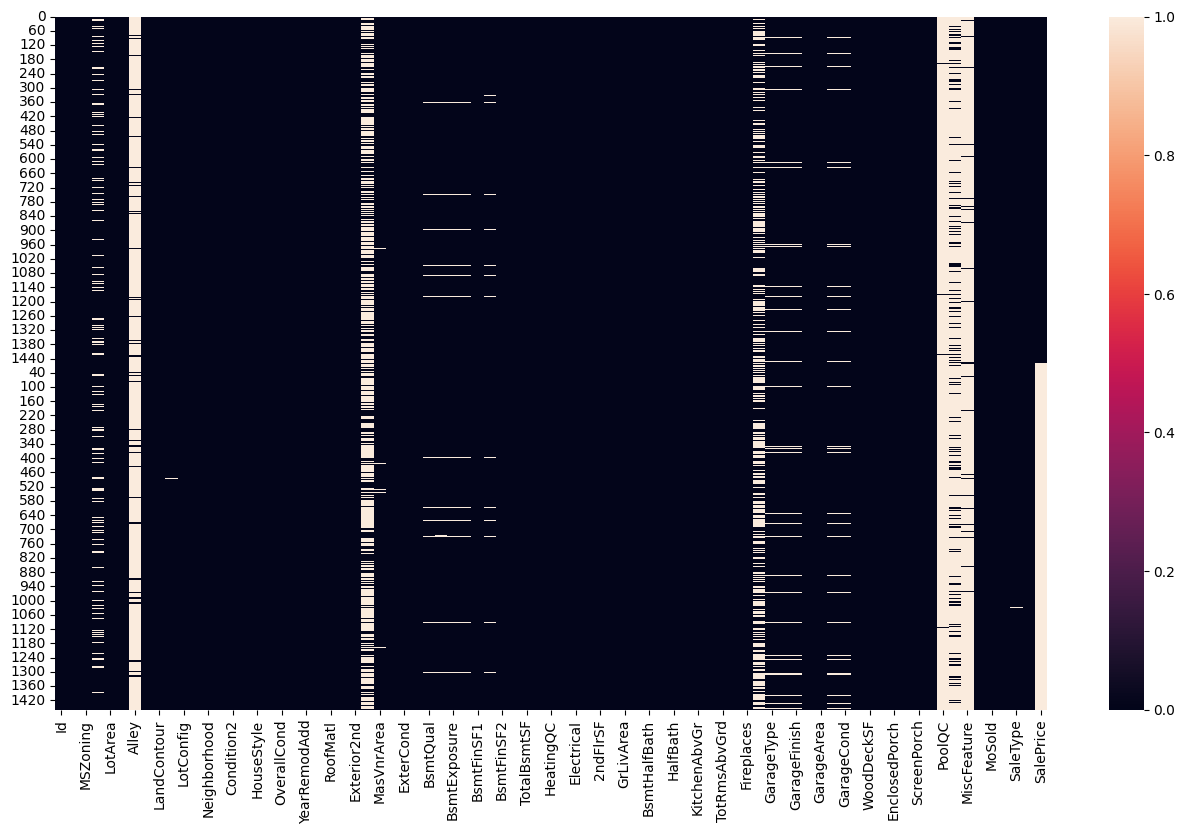

In [18]:
plt.figure(figsize=(16,9))
sns.heatmap(df.isnull())

In [19]:
# The id column does not give us any information, it's an index 
df = df.set_index("Id")

Getting null value percentage per feature

In [20]:
null_count = df.isnull().sum() / df.shape[0] * 100
null_count

MSSubClass        0.000000
MSZoning          0.137033
LotFrontage      16.649538
LotArea           0.000000
Street            0.000000
Alley            93.216855
LotShape          0.000000
LandContour       0.000000
Utilities         0.068517
LotConfig         0.000000
LandSlope         0.000000
Neighborhood      0.000000
Condition1        0.000000
Condition2        0.000000
BldgType          0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
RoofStyle         0.000000
RoofMatl          0.000000
Exterior1st       0.034258
Exterior2nd       0.034258
MasVnrType       60.500171
MasVnrArea        0.787941
ExterQual         0.000000
ExterCond         0.000000
Foundation        0.000000
BsmtQual          2.774923
BsmtCond          2.809181
BsmtExposure      2.809181
BsmtFinType1      2.706406
BsmtFinSF1        0.034258
BsmtFinType2      2.740665
BsmtFinSF2        0.034258
BsmtUnfSF         0.034258
T

Dropping features / columns 

In [21]:
# Setting the throshold value of 50 percent
features_below_50_percent = null_count[null_count > 50]
features_below_50_percent

Alley          93.216855
MasVnrType     60.500171
PoolQC         99.657417
Fence          80.438506
MiscFeature    96.402878
dtype: float64

Here these features contain maximum NA values . (The obvious thought comes to mind is to remove these features from the dataframe)
But when consulting the dataset documentation the NA values represent that there is 
no alley connecting to the place
no pool
no fence and so on 
We can not remove these features from the data frame as these features do not contain any missing values instead they respresent that particular features is not present in the house 

In [22]:
features_20_50 = null_count[((null_count > 20) & (null_count < 51))]
features_20_50

FireplaceQu    48.646797
SalePrice      49.982871
dtype: float64

As SalePrice is our target column we can not remove this feature from our dataset
while as FirePlaceQuality has 48 percent missing value but when consulting the documentation of the dataset the missing values i.e NA represent that there is no fire place at that particular house meaning we cannot remove this feature from our data set as well

In [23]:
features_5_20 = null_count[((null_count > 5) & (null_count < 21))]
features_5_20

LotFrontage     16.649538
GarageType       5.378554
GarageYrBlt      5.447071
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
dtype: float64

From observation the Garage related columns have same pattern in year built, finish, quality, condition that is because if there is no garage (GarageType = NA (No Garage)) then there is no point of finish, quality,conditon etc. So we can not remove the garage related columns as well
LotFrontage represents that feets of road that connects to the house. This feature is important to my dataset as it plays a role in predicting the price of the house. Instead of dropping the column we will fill the missing values

## Missing Value Imputation

In [24]:
missing_features = null_count[null_count > 0]
print(f"There are {len(missing_features)} features with missing values in the dataset")
print(missing_features)

There are 35 features with missing values in the dataset
MSZoning         0.137033
LotFrontage     16.649538
Alley           93.216855
Utilities        0.068517
Exterior1st      0.034258
Exterior2nd      0.034258
MasVnrType      60.500171
MasVnrArea       0.787941
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinSF1       0.034258
BsmtFinType2     2.740665
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
Electrical       0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517
KitchenQual      0.034258
Functional       0.068517
FireplaceQu     48.646797
GarageType       5.378554
GarageYrBlt      5.447071
GarageFinish     5.447071
GarageCars       0.034258
GarageArea       0.034258
GarageQual       5.447071
GarageCond       5.447071
PoolQC          99.657417
Fence           80.438506
MiscFeature     96.402878
SaleType         0.034258
SalePrice       49.982871
dtype: float64


Getting the categorical features containing missing values

In [25]:
cat_na_features = missing_features[missing_features.keys().isin(cat_features)]
print(f"There are {len(cat_na_features)} number of features with missing values")
print("They are :")
print(cat_na_features)

There are 23 number of features with missing values
They are :
MSZoning         0.137033
Alley           93.216855
Utilities        0.068517
Exterior1st      0.034258
Exterior2nd      0.034258
MasVnrType      60.500171
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinType2     2.740665
Electrical       0.034258
KitchenQual      0.034258
Functional       0.068517
FireplaceQu     48.646797
GarageType       5.378554
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
PoolQC          99.657417
Fence           80.438506
MiscFeature     96.402878
SaleType         0.034258
dtype: float64


Getting integer features with missing values

In [26]:
int_na_features = missing_features[missing_features.keys().isin(int_features)]
print(f"There are {len(int_na_features)} number of features with missing values")
print("They are :")
print(int_na_features)

There are 0 number of features with missing values
They are :
Series([], dtype: float64)


Getting float features with missing values

In [27]:
float_na_features = missing_features[missing_features.keys().isin(float_features)]
print(f"There are {len(float_na_features)} number of features with missing values")
print("They are :")
print(float_na_features)

There are 12 number of features with missing values
They are :
LotFrontage     16.649538
MasVnrArea       0.787941
BsmtFinSF1       0.034258
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517
GarageYrBlt      5.447071
GarageCars       0.034258
GarageArea       0.034258
SalePrice       49.982871
dtype: float64


### Handling MSZoning = 0.137033

In [28]:
df['MSZoning'].value_counts()

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='MSZoning'>

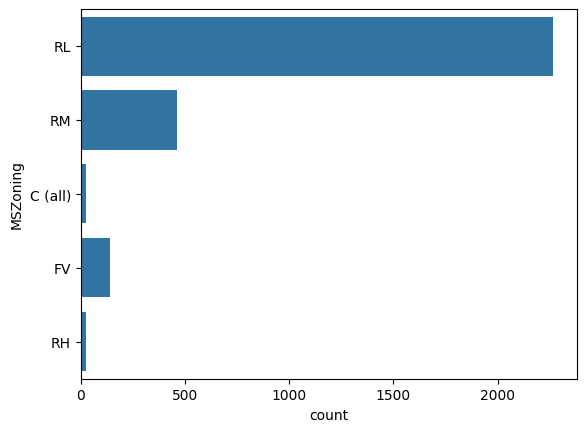

In [29]:
sns.countplot(df['MSZoning'])

In [30]:
mszoning_mode = df['MSZoning'].mode()[0]
mszoning_mode

'RL'

In [31]:
df['MSZoning'].isnull().sum()

4

In [32]:
df['MSZoning'].replace(np.nan, mszoning_mode, inplace = True)
df['MSZoning'].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\2123905989.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MSZoning'].replace(np.nan, mszoning_mode, inplace = True)


0

### Handling Alley 93.216855

In [33]:
df['Alley'].value_counts()

Alley
Grvl    120
Pave     78
Name: count, dtype: int64

In [34]:
df['Alley'].isnull().sum()

2721

In [35]:
alley_const = "NA"
df['Alley'].replace(np.nan,alley_const,inplace=True)

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\883707017.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Alley'].replace(np.nan,alley_const,inplace=True)


<Axes: xlabel='count', ylabel='Alley'>

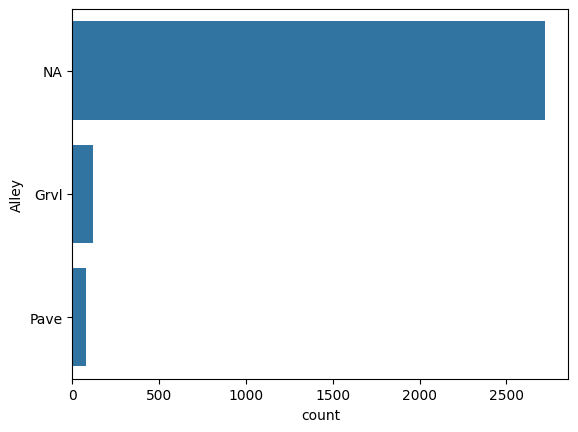

In [36]:
df['Alley'].isnull().sum()
sns.countplot(df['Alley'])

### Handling LotFrontage 16.649538

<Axes: ylabel='LotFrontage'>

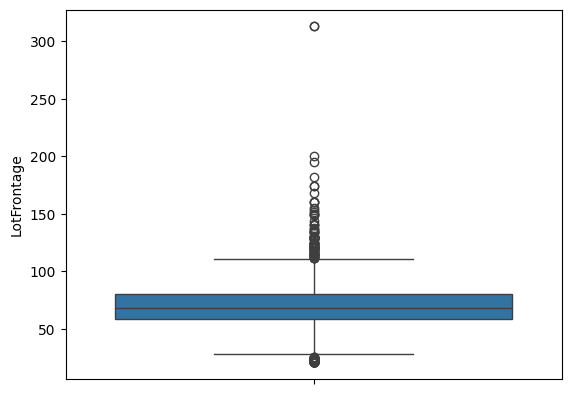

In [37]:
# In numerical features we have to watch out for outliers . this can be done in many ways . one way is to use boxplot
sns.boxplot(df['LotFrontage'])

In this boxplot it clearly shows that it has many number of outliers
in this case we can not use the mean value for imputation as mean value is influenced by outliers
instead using median value for imputing

<Axes: xlabel='LotFrontage', ylabel='Count'>

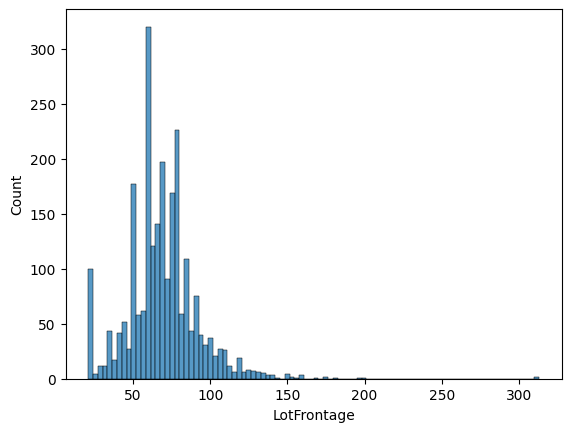

In [38]:
sns.histplot(df['LotFrontage'])

In [39]:
df['LotFrontage'].isnull().sum()

486

In [40]:
lotfrontage_median = df['LotFrontage'].median()
df['LotFrontage'].replace(np.nan,lotfrontage_median,inplace=True)

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\2752434010.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LotFrontage'].replace(np.nan,lotfrontage_median,inplace=True)


In [41]:
df['LotFrontage'].isnull().sum()

0

### Handling Utilities 0.068517

In [42]:
df['Utilities'].value_counts()

Utilities
AllPub    2916
NoSeWa       1
Name: count, dtype: int64

In [43]:
df['Utilities'].isnull().sum()

2

In [44]:
utilities_mode = df['Utilities'].mode()[0]
df['Utilities'].replace(np.nan,utilities_mode,inplace=True)
df['Utilities'].isnull().sum()


C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\2325177451.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Utilities'].replace(np.nan,utilities_mode,inplace=True)


0

### Handling Exterior1st 0.034258 and Exterior2nd 0.034258

In [45]:
df['Exterior1st'].value_counts()

Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
Name: count, dtype: int64

In [46]:
df['Exterior2nd'].value_counts()

Exterior2nd
VinylSd    1014
MetalSd     447
HdBoard     406
Wd Sdng     391
Plywood     270
CmentBd     126
Wd Shng      81
BrkFace      47
Stucco       47
AsbShng      38
Brk Cmn      22
ImStucc      15
Stone         6
AsphShn       4
CBlock        3
Other         1
Name: count, dtype: int64

In [47]:
exterior_first_mode = df['Exterior1st'].mode()[0]
exterior_sec_mode = df['Exterior2nd'].mode()[0]

In [48]:
df['Exterior1st'].replace(np.nan,exterior_first_mode,inplace=True)
df['Exterior2nd'].replace(np.nan,exterior_sec_mode,inplace=True)
df['Exterior1st'].isnull().sum()
df['Exterior2nd'].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\1282605439.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Exterior1st'].replace(np.nan,exterior_first_mode,inplace=True)
C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\1282605439.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

0

### Handling MasVnrType 60.500171 and MasVnrArea 0.787941

In [49]:
df['MasVnrType'].value_counts()

MasVnrType
BrkFace    879
Stone      249
BrkCmn      25
Name: count, dtype: int64

In [50]:
df['MasVnrType'].isnull().sum()

1766

In [51]:
masvnrtype_const = 'None'
df['MasVnrType'].replace(np.nan,masvnrtype_const,inplace=True)
df['MasVnrType'].isnull().sum()


C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\3372499416.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MasVnrType'].replace(np.nan,masvnrtype_const,inplace=True)


0

In [52]:
df['MasVnrType'].value_counts()

MasVnrType
None       1766
BrkFace     879
Stone       249
BrkCmn       25
Name: count, dtype: int64

In [53]:
df['MasVnrArea'].isnull().sum()

23

<Axes: xlabel='MasVnrArea', ylabel='Count'>

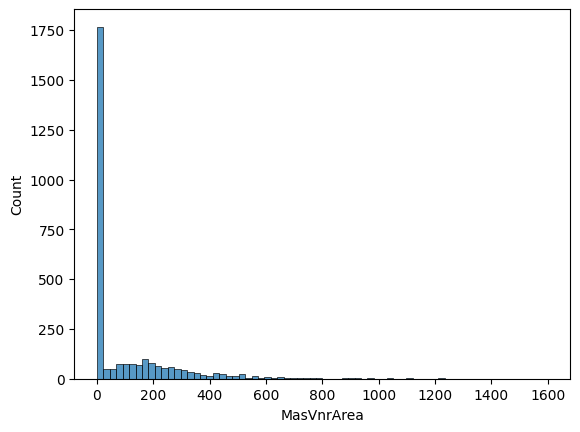

In [54]:
sns.histplot(df['MasVnrArea'])

<Axes: ylabel='MasVnrArea'>

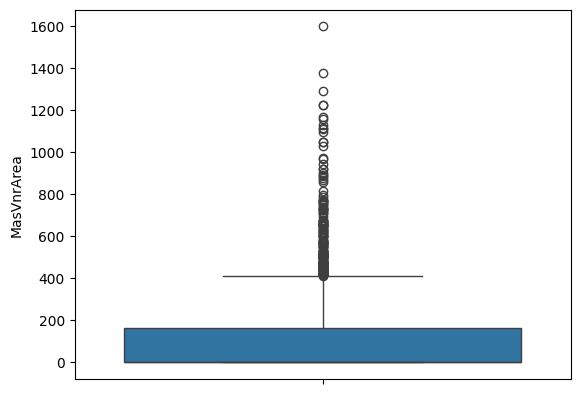

In [55]:
sns.boxplot(df['MasVnrArea'])

In [56]:
### This feature has too many outliers so we have to fill in the missing values with median
masvnsr_median = df['MasVnrArea'].median()
df['MasVnrArea'].replace(np.nan,masvnsr_median,inplace=True)
df['MasVnrArea'].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\2578710364.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MasVnrArea'].replace(np.nan,masvnsr_median,inplace=True)


0

### Handling Bsmt feature

In [57]:

cat_bsmt_feature = ['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']
num_bsmt_feature = ['BsmtFinSF1','BsmtFullBath','BsmtHalfBath','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF']

<Axes: ylabel='Id'>

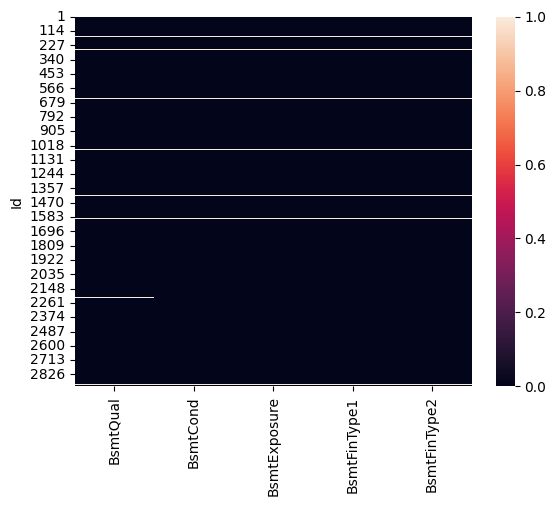

In [58]:
sns.heatmap(df[cat_bsmt_feature].isnull())

categorical features of basement

In [59]:
for i in cat_bsmt_feature:
    print(f"The value count of {i} is : {df[i].value_counts()}")

The value count of BsmtQual is : BsmtQual
TA    1283
Gd    1209
Ex     258
Fa      88
Name: count, dtype: int64
The value count of BsmtCond is : BsmtCond
TA    2606
Gd     122
Fa     104
Po       5
Name: count, dtype: int64
The value count of BsmtExposure is : BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
Name: count, dtype: int64
The value count of BsmtFinType1 is : BsmtFinType1
Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
Name: count, dtype: int64
The value count of BsmtFinType2 is : BsmtFinType2
Unf    2493
Rec     105
LwQ      87
BLQ      68
ALQ      52
GLQ      34
Name: count, dtype: int64


All these contain missing values but when consulting the documentation of the dataset , the missing values depict that there is no basement available so we will fill the missing values with NA (not available)

In [60]:
df[cat_bsmt_feature].isnull().sum()

BsmtQual        81
BsmtCond        82
BsmtExposure    82
BsmtFinType1    79
BsmtFinType2    80
dtype: int64

In [61]:
bsmt_cat_const = "NA"
for i in cat_bsmt_feature:
   df[i].replace(np.nan,bsmt_cat_const,inplace=True)

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\3115366461.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].replace(np.nan,bsmt_cat_const,inplace=True)


In [62]:
df[cat_bsmt_feature].isnull().sum()

BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

Numerical features of basement

In [63]:
df[num_bsmt_feature].isnull().sum()

BsmtFinSF1      1
BsmtFullBath    2
BsmtHalfBath    2
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
dtype: int64

<Axes: ylabel='Id'>

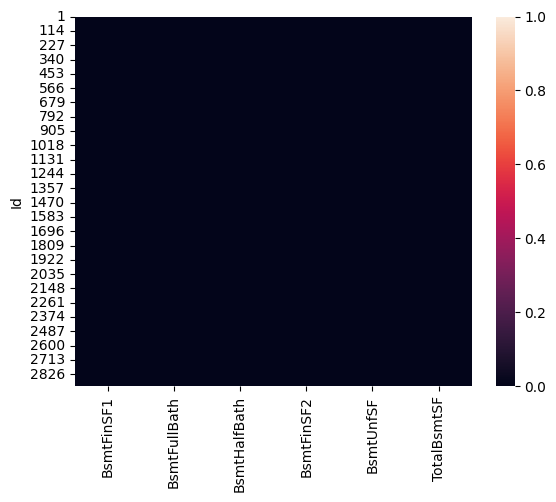

In [64]:
sns.heatmap(df[num_bsmt_feature].isnull())

As the number of missing value is very less. From the dataset itself if there is no basement it can not have any basement numerical value . no basement no rating, area etc. These few missing values are present where the catagorical feature depict that there is no basement so it is advisable to fill the missing values with 0

In [65]:
bsmt_num = 0
for i in num_bsmt_feature:
    df[i].replace(np.nan, bsmt_num,inplace=True)
df[num_bsmt_feature].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\2629390011.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].replace(np.nan, bsmt_num,inplace=True)


BsmtFinSF1      0
BsmtFullBath    0
BsmtHalfBath    0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
dtype: int64

### Handling kitchen quality and electrical features as both features have similar percentage of missing value and both are catagorical

In [66]:
df['Electrical'].value_counts()

Electrical
SBrkr    2671
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: count, dtype: int64

In [67]:
df['Electrical'].isnull().sum()

1

In [68]:
df['KitchenQual'].value_counts()

KitchenQual
TA    1492
Gd    1151
Ex     205
Fa      70
Name: count, dtype: int64

In [69]:
df['KitchenQual'].isnull().sum()

1

In [70]:
df_ke = df[['KitchenQual','Electrical']]
df_ke[df_ke.isnull().any(axis=1)]

,KitchenQual,Electrical
Id,,
1380,Gd,NaN
1556,NaN,SBrkr


As both the features are categorical and both the missing values don't coincide with each other so the safe bet is to replace the missing values with mode as the documentation does not imply the possibility of non availaibility of that particular feature

In [71]:
elec_mode = df['Electrical'].mode()[0]
df['Electrical'].replace(np.nan, elec_mode,inplace=True)
df['Electrical'].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\180758075.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Electrical'].replace(np.nan, elec_mode,inplace=True)


0

In [72]:
kit_mode = df['KitchenQual'].mode()[0]
df['KitchenQual'].replace(np.nan, kit_mode,inplace=True)
df['KitchenQual'].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\4203165592.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['KitchenQual'].replace(np.nan, kit_mode,inplace=True)


0

### Handling Functional feature

In [73]:
df['Functional'].value_counts()

Functional
Typ     2717
Min2      70
Min1      65
Mod       35
Maj1      19
Maj2       9
Sev        2
Name: count, dtype: int64

In [74]:
df['Functional'].isnull().sum()

2

As functional feature is a categorical feature we will replace the missing values with mode of functional feature as the documentation does not imply any chance of NA or none 

In [75]:
func_mode = df['Functional'].mode()[0]
df['Functional'].replace(np.nan, func_mode,inplace=True)
df['Functional'].isnull().sum()


C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\4013058633.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Functional'].replace(np.nan, func_mode,inplace=True)


0

### Handling SaleType

In [76]:
df['SaleType'].value_counts()

SaleType
WD       2525
New       239
COD        87
ConLD      26
CWD        12
ConLI       9
ConLw       8
Oth         7
Con         5
Name: count, dtype: int64

In [77]:
df['SaleType'].isnull().sum()

1

Replacing the missing values with mode of the feature as the documentation does not imply any chance of non availability of the functionality

In [78]:
sale_mode = df['SaleType'].mode()[0]
df['SaleType'].replace(np.nan, sale_mode,inplace=True)
df['SaleType'].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\428937673.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SaleType'].replace(np.nan, sale_mode,inplace=True)


0

### Handling FireplaceQuality

In [79]:
df['FireplaceQu'].value_counts()

FireplaceQu
Gd    744
TA    592
Fa     74
Po     46
Ex     43
Name: count, dtype: int64

In [80]:
df['FireplaceQu'].isnull().sum()

1420

As per the documentation of the dataset, missing values imply that there is no fire place at that house. So replace all the missing value with global constant i.e "NA"

In [81]:
fireplaceQ_const = "NA"
df['FireplaceQu'].replace(np.nan, fireplaceQ_const,inplace=True)
df['FireplaceQu'].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\1390637018.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].replace(np.nan, fireplaceQ_const,inplace=True)


0

### Handling poolQuality

In [82]:
df['PoolQC'].value_counts()

PoolQC
Ex    4
Gd    4
Fa    2
Name: count, dtype: int64

In [83]:
df['PoolQC'].isnull().sum()

2909

As per the documentation the missing values mean that there is no pool available at that house
So replace the missing value with "NA"

In [84]:
PoolQC_const = "NA"
df['PoolQC'].replace(np.nan, PoolQC_const,inplace=True)
df['PoolQC'].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\724294806.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PoolQC'].replace(np.nan, PoolQC_const,inplace=True)


0

### Handling Fence

In [85]:
df['Fence'].value_counts()

Fence
MnPrv    329
GdPrv    118
GdWo     112
MnWw      12
Name: count, dtype: int64

In [86]:
df['Fence'].isnull().sum()

2348

As per the documetation missing values mean that there are no fences at the house so replacing these missing values with NA, meaning not available

In [87]:
Fence_const = "NA"
df['Fence'].replace(np.nan, Fence_const,inplace=True)
df['Fence'].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\1597094420.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fence'].replace(np.nan, Fence_const,inplace=True)


0

### Handling MiscFeatures

In [88]:
df['MiscFeature'].value_counts()

MiscFeature
Shed    95
Gar2     5
Othr     4
TenC     1
Name: count, dtype: int64

In [89]:
df['MiscFeature'].isnull().sum()

2814

As per the documentation missing values imply that there are no miscellenous features or function available at the house. 
So replacing the missing values with NA

In [90]:
MiscFeature_const = "NA"
df['MiscFeature'].replace(np.nan, MiscFeature_const,inplace=True)
df['MiscFeature'].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\1195260414.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MiscFeature'].replace(np.nan, MiscFeature_const,inplace=True)


0

### Handling all the garage related categorical features
GarageType       5.378554
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071

In [91]:
garage_cat = ['GarageType','GarageFinish','GarageQual','GarageCond']

In [92]:
for i in garage_cat:
    print(f'The value counts of {df[i].value_counts()}')

The value counts of GarageType
Attchd     1723
Detchd      779
BuiltIn     186
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64
The value counts of GarageFinish
Unf    1230
RFn     811
Fin     719
Name: count, dtype: int64
The value counts of GarageQual
TA    2604
Fa     124
Gd      24
Po       5
Ex       3
Name: count, dtype: int64
The value counts of GarageCond
TA    2654
Fa      74
Gd      15
Po      14
Ex       3
Name: count, dtype: int64


In [93]:
df[garage_cat].isnull().sum()

GarageType      157
GarageFinish    159
GarageQual      159
GarageCond      159
dtype: int64

As per the documentation missing value here implies that there is no garage available in the house so replacing the missing values with NA meaning not available

In [94]:
garage_cat_const = "NA"
for feat in garage_cat:
    df[feat].replace(np.nan, garage_cat_const,inplace=True)
df[garage_cat].isnull().sum()


C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\3467103795.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feat].replace(np.nan, garage_cat_const,inplace=True)


GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
dtype: int64

### Handling numerical features of the garage
GarageYrBlt      5.447071
GarageCars       0.034258
GarageArea       0.034258

In [95]:
garage_num_feat = ['GarageYrBlt','GarageArea','GarageCars']
df[garage_num_feat].isnull().sum()

GarageYrBlt    159
GarageArea       1
GarageCars       1
dtype: int64

In [96]:
df_garage = df[['GarageType'] + garage_num_feat]
df_garage[df_garage.isnull().any(axis=1)]

,GarageType,GarageYrBlt,GarageArea,GarageCars
Id,,,,
40,NA,NaN,0.0,0.0
49,NA,NaN,0.0,0.0
79,NA,NaN,0.0,0.0
89,NA,NaN,0.0,0.0
90,NA,NaN,0.0,0.0
100,NA,NaN,0.0,0.0
109,NA,NaN,0.0,0.0
126,NA,NaN,0.0,0.0
128,NA,NaN,0.0,0.0


From this dataframe we can clearly see that when there is no garage available then the year build , cars values are either zero or missing meaning all the missing values imply that the house doesn't have a garage. So replacing all the missing values with zero meaning not available

In [97]:
garage_num_const = 0
for feat in garage_num_feat:
    df[feat].replace(np.nan, garage_num_const,inplace=True)
df[garage_num_feat].isnull().sum()

C:\Users\suhai\AppData\Local\Temp\ipykernel_5136\415748501.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feat].replace(np.nan, garage_num_const,inplace=True)


GarageYrBlt    0
GarageArea     0
GarageCars     0
dtype: int64

### Finalizing value imputation

In [98]:
df.isnull().any(axis=1).sum()

1459

These missing values belong to the sale price i.e our target variable

## Converting Numerical Features in Categorical Features
MSSubClass YearBuilt YearRemodAdd GarageYrBlt MoSold YrSold

In [99]:
df['MoSold'].unique()

array([ 2,  5,  9, 12, 10,  8, 11,  4,  1,  7,  3,  6], dtype=int64)

In [100]:
months_abbr = ["None","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

Change the numerical months into month name using apply function

In [101]:
df['MoSold'] = df['MoSold'].apply(lambda x : months_abbr[x])

In [102]:
df['MoSold'].unique()

array(['Feb', 'May', 'Sep', 'Dec', 'Oct', 'Aug', 'Nov', 'Apr', 'Jan',
       'Jul', 'Mar', 'Jun'], dtype=object)

In [103]:
num_to_cat_feat = ["MSSubClass","YearBuilt","YearRemodAdd","GarageYrBlt","YrSold"]

In [104]:
for feat in num_to_cat_feat:
    print(f"The dtype of {feat} is {df[feat].dtype}")

The dtype of MSSubClass is int64
The dtype of YearBuilt is int64
The dtype of YearRemodAdd is int64
The dtype of GarageYrBlt is float64
The dtype of YrSold is int64


In [105]:
for feat in num_to_cat_feat:
    df[feat]=df[feat].astype(str)

In [106]:
for feat in num_to_cat_feat:
    print(f"The dtype of {feat} is {df[feat].dtype}")

The dtype of MSSubClass is object
The dtype of YearBuilt is object
The dtype of YearRemodAdd is object
The dtype of GarageYrBlt is object
The dtype of YrSold is object


## Converting Categorical features into Numerical features

These features are in categorical form and our machine learning will not be able to understand categorical data. These feature show they contain ordinal data meaning categorical data with some order e.g quality.
So using Ordinal encoding we are converting these features into numerical features

In [107]:
df['ExterQual'].value_counts()

ExterQual
TA    1798
Gd     979
Ex     107
Fa      35
Name: count, dtype: int64

In [108]:
df['ExterQual'] = df['ExterQual'].astype(CategoricalDtype(categories = ["Po","Fa","TA","Gd","Ex"],ordered = True)).cat.codes

In [109]:
df['BsmtExposure'].value_counts()

BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
NA      82
Name: count, dtype: int64

In [110]:
df['BsmtExposure'] = df['BsmtExposure'].astype(CategoricalDtype(categories = ["NA","No","Mn","Av","Gd"],ordered = True)).cat.codes

In [111]:
df['BsmtExposure'].unique()

array([1, 4, 2, 3, 0], dtype=int8)

In [112]:
df['BsmtExposure'].value_counts()

BsmtExposure
1    1904
3     418
4     276
2     239
0      82
Name: count, dtype: int64

In [113]:
df['BsmtFinType1'] = df['BsmtFinType1'].astype(CategoricalDtype(categories=['NA', 'Unf', 'LwQ', 'Rec', 'BLQ','ALQ', 'GLQ'], ordered = True)).cat.codes
df['BsmtFinType2'] = df['BsmtFinType2'].astype(CategoricalDtype(categories=['NA', 'Unf', 'LwQ', 'Rec', 'BLQ','ALQ', 'GLQ'], ordered = True)).cat.codes
df['BsmtQual'] = df['BsmtQual'].astype(CategoricalDtype(categories=['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered = True)).cat.codes
df['ExterCond'] = df['ExterCond'].astype(CategoricalDtype(categories=['Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered = True)).cat.codes
df['Functional'] = df['Functional'].astype(CategoricalDtype(categories=['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod','Min2','Min1', 'Typ'], ordered = True)).cat.codes
df['GarageCond'] = df['GarageCond'].astype(CategoricalDtype(categories=['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered = True)).cat.codes
df['GarageQual'] = df['GarageQual'].astype(CategoricalDtype(categories=['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered = True)).cat.codes
df['GarageFinish'] = df['GarageFinish'].astype(CategoricalDtype(categories=['NA', 'Unf', 'RFn', 'Fin'], ordered = True)).cat.codes
df['HeatingQC'] = df['HeatingQC'].astype(CategoricalDtype(categories=['Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered = True)).cat.codes
df['KitchenQual'] = df['KitchenQual'].astype(CategoricalDtype(categories=['Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered = True)).cat.codes
df['PavedDrive'] = df['PavedDrive'].astype(CategoricalDtype(categories=['N', 'P', 'Y'], ordered = True)).cat.codes
df['Utilities'] = df['Utilities'].astype(CategoricalDtype(categories=['ELO', 'NASeWa', 'NASeWr', 'AllPub'], ordered = True)).cat.codes
df['BsmtCond'] = df['BsmtCond'].astype(CategoricalDtype(categories=['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered = True)).cat.codes
df['FireplaceQu'] = df['FireplaceQu'].astype(CategoricalDtype(categories=['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered = True)).cat.codes
df['PoolQC'] = df['PoolQC'].astype(CategoricalDtype(categories=['NA', 'Fa', 'TA', 'Gd', 'Ex'], ordered = True)).cat.codes
df['BsmtFinSF1'] = df['BsmtFinSF1'].astype(CategoricalDtype(categories=['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ','GLQ'], ordered = True)).cat.codes

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 1 to 2919
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   object 
 1   MSZoning       2919 non-null   object 
 2   LotFrontage    2919 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          2919 non-null   object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2919 non-null   int8   
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuilt    

### One hot encoding

In [115]:
object_features = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Total number of objects are : {len(object_features)}")
print(object_features)

Total number of objects are : 32
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'GarageYrBlt', 'Fence', 'MiscFeature', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition']


In [116]:
df_encode = df.copy()

In [117]:
print(f'The shape of dataframe before encoding is : {df_encode.shape}')

The shape of dataframe before encoding is : (2919, 80)


In [118]:
df_encode = pd.get_dummies(df_encode,prefix=object_features,columns=object_features, drop_first=True)

In [119]:
df_encode.select_dtypes(include=["object"]).columns.tolist()

[]

In [120]:
print(f"The shape of df_encode after one hot encoding is : {df_encode.shape}")

The shape of df_encode after one hot encoding is : (2919, 513)


## Splitting data frame into test and train

In [121]:
df_train.shape

(1460, 81)

In [122]:
len_train = df_train.shape[0]

In [123]:

x_train = df_encode[:len_train].drop("SalePrice", axis=1) 
y_train = df_encode[:len_train]["SalePrice"]

x_test = df_encode[len_train:].drop("SalePrice", axis=1)
print(f"The shape of x_train data set is : {x_train.shape}")
print(f"The shape of x_test is : {x_test.shape}")
print(f"The shape of y_train data set is : {y_train.shape}")

The shape of x_train data set is : (1460, 512)
The shape of x_test is : (1459, 512)
The shape of y_train data set is : (1460,)


## Feature Engineering

In [124]:
sc = StandardScaler()

In [125]:
sc.fit(x_train)

StandardScaler()

In [126]:
x_train = sc.transform(x_train)
x_test = sc.transform(x_test)


## Training ML Models

In [127]:
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor

In [128]:
svr = SVR()
lr = LinearRegression()
sgdr = SGDRegressor()
knr = KNeighborsRegressor()
gpr = GaussianProcessRegressor()
dtr = DecisionTreeRegressor()
gbr = GradientBoostingRegressor()
rfr = RandomForestRegressor()
xgbr = XGBRegressor()

mlpr = MLPRegressor()

In [129]:
models = {"a": ["LinearRegression", lr],
"b":["SVR", svr],
"c": ["SGDRegressor", sgdr],
"d":["KNeighborsRegressor", knr],
"e": ["GaussianProcessRegressor", gpr],
"f":["DecisionTreeRegressor", dtr],
"g": ["GradientBoostingRegressor", gbr],
"h":["RandomForestRegressor", rfr],
"i": ["XGBRegressor", xgbr],
"j": ["MLPRegressor", mlpr],}

In [130]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score

def test_model(model, X_train=x_train, y_train=y_train):
    cv = KFold(n_splits = 7, shuffle=True, random_state = 45)
    r2 = make_scorer(r2_score)
    r2_val_score = cross_val_score(model, X_train, y_train, cv=cv, scoring =r2)
    score = [r2_val_score.mean()]
    return score

In [131]:
models_score = []
for model in models:
    print("Training model : ", models[model][0])
    score = test_model(models[model][1], x_train, y_train)
    print("Score of model : ", score)
    models_score.append([models[model][0], score[0]])

Training model :  LinearRegression
Score of model :  [-4.9833402896957656e+23]
Training model :  SVR
Score of model :  [-0.05213155159351625]
Training model :  SGDRegressor
Score of model :  [-3247.124957155024]
Training model :  KNeighborsRegressor
Score of model :  [0.5618399714885038]
Training model :  GaussianProcessRegressor
Score of model :  [-5.398902754094135]
Training model :  DecisionTreeRegressor
Score of model :  [0.7114404827857995]
Training model :  GradientBoostingRegressor
Score of model :  [0.8661921459236473]
Training model :  RandomForestRegressor
Score of model :  [0.8460161994503873]
Training model :  XGBRegressor
Score of model :  [0.8565911957884583]
Training model :  MLPRegressor


C:\Users\suhai\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\suhai\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\suhai\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\suhai\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.wa

Score of model :  [-4.824197165549933]


C:\Users\suhai\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
